# E-commerce Revenue Analytics

**Domain:** E-commerce / Retail Analytics

**Dataset:** Online Retail II (UCI) -- https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

**Skills:** SQL, Data Cleaning, EDA, KPI Design, Dashboard Development, Business Storytelling

**Tools:** Python, Pandas, SQLite/SQL, Matplotlib, Power BI

---

### Problem Statement
An online retailer wants a single source of truth for revenue performance. Leadership needs to know which products, countries, and time periods drive revenue, which customers keep coming back, and where the business is leaking money -- without waiting on ad-hoc spreadsheet requests.


In [1]:
!pip install -q kagglehub

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
import sqlite3
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)
        df = pd.read_csv(full_path)
        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


# fake data maker, matches the online retail columns in case kaggle download fails
def make_fake_online_retail(n_rows=2000):
    np.random.seed(42)
    products = ['MUG', 'CANDLE', 'LAMP', 'NOTEBOOK', 'PILLOW', 'BASKET', 'FRAME', 'CLOCK']
    countries = ['United Kingdom', 'Germany', 'France', 'Spain', 'Netherlands']
    dates = pd.date_range('2023-01-01', '2023-12-31', periods=n_rows)
    return pd.DataFrame({
        'Invoice': np.random.randint(100000, 999999, n_rows).astype(str),
        'Description': np.random.choice(products, n_rows),
        'Quantity': np.random.randint(1, 15, n_rows),
        'InvoiceDate': dates,
        'Price': np.round(np.random.uniform(2, 50, n_rows), 2),
        'Customer ID': np.random.randint(10000, 10500, n_rows),
        'Country': np.random.choice(countries, n_rows),
    })

### Step 1: Load Data

In [3]:
# 1. LOAD DATA (real dataset if possible, fake backup if not)
df = load_dataset_safe('mashlyn/online-retail-ii-uci', 'online_retail_II.csv', make_fake_online_retail)

# the real kaggle file uses InvoiceNo/UnitPrice/CustomerID, renaming them here so the
# rest of the code (and the fake backup data) can just use one consistent set of names
df = df.rename(columns={'InvoiceNo': 'Invoice', 'UnitPrice': 'Price', 'CustomerID': 'Customer ID'})

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
loaded real dataset from kaggle, 1067371 rows


### Step 2: Clean It Up

In [4]:
# 2. CLEAN IT UP
df = df[~df['Invoice'].astype(str).str.startswith('C')]   # dropping cancelled orders
df = df.dropna(subset=['Customer ID'])                      # dropping rows with no customer
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]            # dropping weird negative rows
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Step 3: Make The Revenue Column

In [5]:
# 3. MAKE THE REVENUE COLUMN
df['Revenue'] = df['Quantity'] * df['Price']

### Step 4: Put It Into Sql So We Can Query It Like A Real Analyst Would

In [6]:
# 4. PUT IT INTO SQL SO WE CAN QUERY IT LIKE A REAL ANALYST WOULD
conn = sqlite3.connect(':memory:')
df.to_sql('online_retail', conn, if_exists='replace', index=False)

805549

### Step 5: The Big 4 Queries Every Stakeholder Asks For

In [7]:
# 5. THE BIG 4 QUERIES EVERY STAKEHOLDER ASKS FOR
monthly_revenue = pd.read_sql("""
    SELECT strftime('%Y-%m', InvoiceDate) AS month, SUM(Revenue) AS revenue
    FROM online_retail GROUP BY month ORDER BY month
""", conn)

top_products = pd.read_sql("""
    SELECT Description, SUM(Revenue) AS revenue
    FROM online_retail GROUP BY Description ORDER BY revenue DESC LIMIT 10
""", conn)

revenue_by_country = pd.read_sql("""
    SELECT Country, SUM(Revenue) AS revenue
    FROM online_retail GROUP BY Country ORDER BY revenue DESC
""", conn)

### Step 6: Repeat Customer Rate

In [8]:
# 6. REPEAT CUSTOMER RATE (how many people bought in more than 1 month)
cust_months = df.groupby('Customer ID')['InvoiceDate'].apply(lambda x: x.dt.to_period('M').nunique())
repeat_rate = (cust_months > 1).mean()
print(f"repeat customer rate: {repeat_rate:.1%}")

aov = df.groupby('Invoice')['Revenue'].sum().mean()
print(f"average order value: {aov:.2f}")

repeat customer rate: 69.8%
average order value: 479.95


### Step 7: Charts

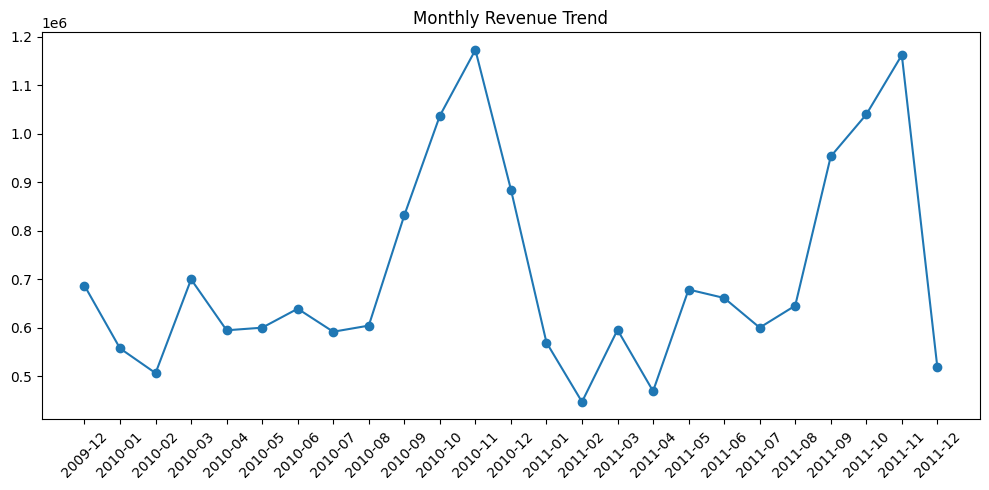

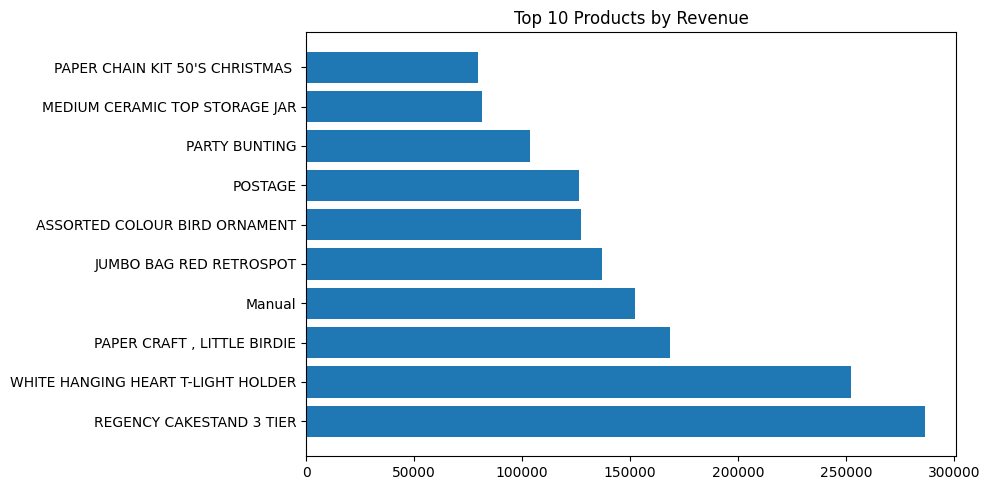

In [9]:
# 7. CHARTS
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_products['Description'], top_products['revenue'])
plt.title('Top 10 Products by Revenue')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

### Step 8: Save Stuff For Power Bi

In [10]:
# 8. SAVE STUFF FOR POWER BI
monthly_revenue.to_csv('monthly_revenue.csv', index=False)
top_products.to_csv('top_products.csv', index=False)
revenue_by_country.to_csv('revenue_by_country.csv', index=False)